# Model Training


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from pathlib import Path
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DEFAULT_SCENARIO_CLASS_NAMES = [
    "Botnet",
    "Miner",
    "Trojan-Agent",
    "Coinminer",
    "Cloud Attack",
    "Brute-Force",
    "Data-Caching",
    "Database",
    "Redis",
    "Web-Serving",
]

def load_label_names():
    path = Path("../feature_engineering/label_mapping.json")
    if path.exists():
        with open(path) as f:
            cfg = json.load(f)
        return cfg.get("scenario_class_names", cfg.get("class_names", DEFAULT_SCENARIO_CLASS_NAMES))
    return DEFAULT_SCENARIO_CLASS_NAMES

SCENARIO_CLASS_NAMES = load_label_names()
CLASS_NAMES = SCENARIO_CLASS_NAMES
METADATA_COLS = ["session_id", "pod_name", "namespace", "flow_window"]
TARGET_COLS = ["label", "scenario_label"]

## Load Dataset

In [2]:
syscall_df = pd.read_csv("../feature_engineering/dataset/syscall_dataset.csv")
network_df = pd.read_csv("../feature_engineering/dataset/network_flow_dataset.csv")

def load_label_rules():
    path = Path("../feature_engineering/label_mapping.json")
    if path.exists():
        with open(path) as f:
            cfg = json.load(f)
        return sorted(cfg["rules"], key=lambda rule: len(rule["pattern"]), reverse=True)
    return []

LABEL_RULES = load_label_rules()

def normalize_name(value):
    return (value or "").lower().replace("_", "-")

def infer_label_from_pod(pod_name):
    pod_lower = normalize_name(pod_name)
    for rule in LABEL_RULES:
        if normalize_name(rule["pattern"]) in pod_lower:
            return int(rule.get("scenario_label", rule.get("label")))
    return -1

def ensure_scenario_target(df):
    df = df.copy()

    if "scenario_label" not in df.columns:
        if "pod_name" in df.columns and LABEL_RULES:
            df["scenario_label"] = df["pod_name"].apply(infer_label_from_pod)
            unknown = df[df["scenario_label"] < 0]
            if not unknown.empty:
                print(f"Warning: dropping {len(unknown):,} rows with unknown pod labels")
                print(unknown["pod_name"].value_counts().head(15))
                df = df[df["scenario_label"] >= 0].copy()
        else:
            df["scenario_label"] = df["label"]

    df["label"] = df["scenario_label"]
    return df

syscall_df = ensure_scenario_target(syscall_df)
network_df = ensure_scenario_target(network_df)

print(f"Syscall dataset shape: {syscall_df.shape}")
print(f"Network dataset shape: {network_df.shape}")

print("\nSyscall sample:")
display(syscall_df.head())
print("\nNetwork sample:")
display(network_df.head())

Syscall dataset shape: (1534473, 11)
Network dataset shape: (101007, 26)

Syscall sample:


,session_id,pod_name,namespace,label,scenario_label,ngram_index,n1,n2,n3,n4,n5
0,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,0,45,44,45,45,44
1,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,1,44,45,45,44,45
2,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,2,45,45,44,45,45
3,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,3,45,44,45,45,44
4,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,4,44,45,45,44,44



Network sample:


,session_id,pod_name,namespace,label,scenario_label,flow_window,unique_src_ports,unique_dst_ports,proto_TCP_count,proto_UDP_count,...,flag_SYN_count,flag_ACK_count,flag_RST_count,flag_PSH_count,is_well_known_port_count,is_high_port_count,is_dns_port_count,is_http_port_count,is_db_port_count,is_mining_port_count
0,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,0,1.0,5.0,100.0,0.0,...,2.0,100.0,0.0,98.0,0.0,41.0,0.0,0.0,0.0,0.0
1,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,1,1.0,2.0,100.0,0.0,...,0.0,100.0,0.0,100.0,0.0,41.0,0.0,0.0,0.0,0.0
2,0,flask-postgres-59676499f7-59lfj,benign-workloads,7,7,2,1.0,2.0,84.0,0.0,...,0.0,84.0,0.0,84.0,0.0,41.0,0.0,0.0,0.0,0.0
3,0,flask-postgres-59676499f7-q6h56,benign-workloads,7,7,0,1.0,2.0,100.0,0.0,...,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,flask-postgres-59676499f7-q6h56,benign-workloads,7,7,1,1.0,2.0,100.0,0.0,...,0.0,100.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0


## Exploratory Data Analysis (EDA)

In [3]:
# Info dataset
print("="*50)
print("SYSCALL DATA INFO")
print("="*50)
print(syscall_df.info())

print("\n" + "="*50)
print("NETWORK DATA INFO")
print("="*50)
print(network_df.info())

SYSCALL DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 1534473 entries, 0 to 1534472
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   session_id      1534473 non-null  int64
 1   pod_name        1534473 non-null  str  
 2   namespace       1534473 non-null  str  
 3   label           1534473 non-null  int64
 4   scenario_label  1534473 non-null  int64
 5   ngram_index     1534473 non-null  int64
 6   n1              1534473 non-null  int64
 7   n2              1534473 non-null  int64
 8   n3              1534473 non-null  int64
 9   n4              1534473 non-null  int64
 10  n5              1534473 non-null  int64
dtypes: int64(9), str(2)
memory usage: 128.8 MB
None

NETWORK DATA INFO
<class 'pandas.DataFrame'>
RangeIndex: 101007 entries, 0 to 101006
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   sessio

In [4]:
# Missing values
print("\n" + "="*50)
print("MISSING VALUES - SYSCALL")
print("="*50)
print(syscall_df.isnull().sum())

print("\n" + "="*50)
print("MISSING VALUES - NETWORK")
print("="*50)
print(network_df.isnull().sum())


MISSING VALUES - SYSCALL
session_id        0
pod_name          0
namespace         0
label             0
scenario_label    0
ngram_index       0
n1                0
n2                0
n3                0
n4                0
n5                0
dtype: int64

MISSING VALUES - NETWORK
session_id                  0
pod_name                    0
namespace                   0
label                       0
scenario_label              0
flow_window                 0
unique_src_ports            0
unique_dst_ports            0
proto_TCP_count             0
proto_UDP_count             0
proto_OTHER_count           0
dir_EGRESS_count            0
dir_INGRESS_count           0
verdict_FORWARDED_count     0
verdict_DROPPED_count       0
verdict_TRACED_count        0
flag_SYN_count              0
flag_ACK_count              0
flag_RST_count              0
flag_PSH_count              0
is_well_known_port_count    0
is_high_port_count          0
is_dns_port_count           0
is_http_port_count       


DISTRIBUSI TARGET
Syscall scenario: {0: 483, 1: 43561, 2: 32272, 3: 101890, 4: 110213, 5: 142654, 6: 84965, 7: 226009, 8: 670762, 9: 121664}
Network scenario: {0: 73, 1: 1290, 2: 1127, 3: 18, 4: 1712, 5: 18501, 6: 31125, 7: 4247, 8: 33661, 9: 9253}


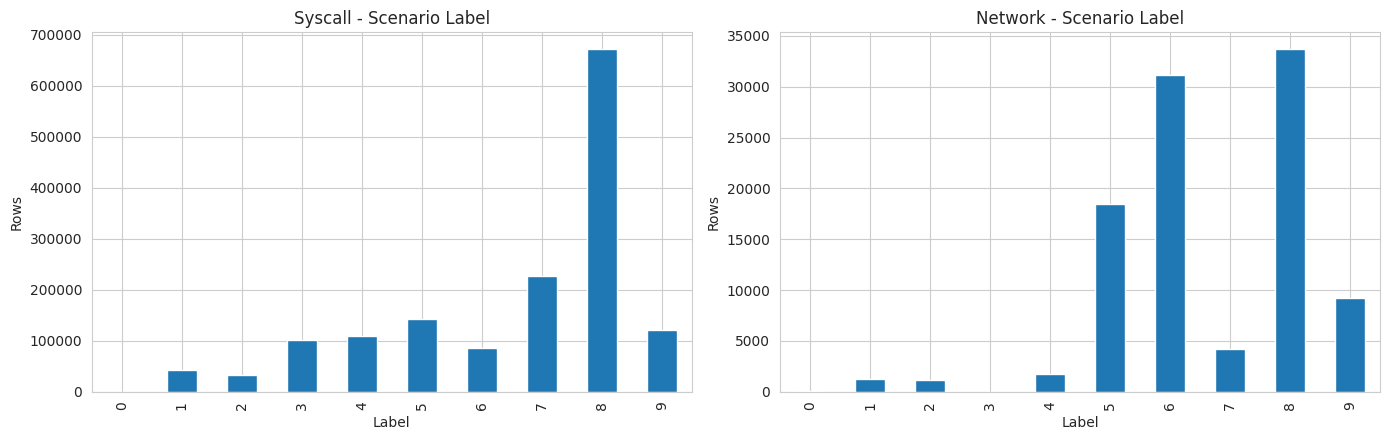

In [5]:
print("\n" + "="*50)
print("DISTRIBUSI TARGET")
print("="*50)
print("Syscall scenario:", syscall_df["scenario_label"].value_counts().sort_index().to_dict())
print("Network scenario:", network_df["scenario_label"].value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
syscall_df["scenario_label"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Syscall - Scenario Label")
network_df["scenario_label"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Network - Scenario Label")
for ax in axes:
    ax.set_xlabel("Label")
    ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()


## Data Preparation

In [6]:
def prepare_xy(df, target_col):
    drop_cols = [col for col in METADATA_COLS + TARGET_COLS if col in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore")
    X = X.select_dtypes(include=[np.number]).fillna(0)
    y = df[target_col].astype(int)
    return X, y

def prepare_xy_syscall(df, target_col):
    """Prepare syscall features using CountVectorizer on ngram_doc column."""
    y = df[target_col].astype(int)
    if "ngram_doc" in df.columns:
        from sklearn.feature_extraction.text import CountVectorizer
        vec = CountVectorizer(token_pattern=r"[^ ]+", min_df=1)
        X_sparse = vec.fit_transform(df["ngram_doc"])
        X = pd.DataFrame(X_sparse.toarray(), columns=vec.get_feature_names_out(), index=df.index)
    else:
        drop_cols = [col for col in METADATA_COLS + TARGET_COLS if col in df.columns]
        X = df.drop(columns=drop_cols, errors="ignore")
        X = X.select_dtypes(include=[np.number]).fillna(0)
    return X, y

X_syscall, y_syscall = prepare_xy_syscall(syscall_df, "scenario_label")
X_network, y_network = prepare_xy(network_df, "scenario_label")

print(f"Syscall features: {X_syscall.shape}")
print(f"Network features: {X_network.shape}")
print(f"Syscall feature columns: {X_syscall.columns.tolist()}")
print(f"Network feature columns: {X_network.columns.tolist()}")


Syscall features: (1534473, 5)
Network features: (101007, 20)
Syscall feature columns: ['n1', 'n2', 'n3', 'n4', 'n5']
Network feature columns: ['unique_src_ports', 'unique_dst_ports', 'proto_TCP_count', 'proto_UDP_count', 'proto_OTHER_count', 'dir_EGRESS_count', 'dir_INGRESS_count', 'verdict_FORWARDED_count', 'verdict_DROPPED_count', 'verdict_TRACED_count', 'flag_SYN_count', 'flag_ACK_count', 'flag_RST_count', 'flag_PSH_count', 'is_well_known_port_count', 'is_high_port_count', 'is_dns_port_count', 'is_http_port_count', 'is_db_port_count', 'is_mining_port_count']


In [7]:
def split_dataset(df, X, y, name):
    groups = df.loc[X.index, "session_id"]
    n_groups = groups.nunique()
    if n_groups > 1:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        train_groups = set(groups.iloc[train_idx])
        test_groups  = set(groups.iloc[test_idx])
        assert not (train_groups & test_groups), "Session leakage detected!"
        split_by = "session_id"
    else:
        # Fallback: split by pod_name to prevent same-pod leakage
        groups = df.loc[X.index, "pod_name"]
        gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        split_by = "pod_name"
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print(f"{name} split: GroupShuffleSplit by {split_by} (no leakage)")
    print(f"{name} - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"{name} train labels: {Counter(y_train)}")
    print(f"{name} test labels : {Counter(y_test)}")
    return X_train, X_test, y_train, y_test

X_train_sys, X_test_sys, y_train_sys, y_test_sys = split_dataset(
    syscall_df, X_syscall, y_syscall, "Syscall Scenario"
)
X_train_net, X_test_net, y_train_net, y_test_net = split_dataset(
    network_df, X_network, y_network, "Network Scenario"
)

# Re-apply SelectKBest only on train to avoid feature selection leakage
from sklearn.feature_selection import SelectKBest, chi2
selector_net = SelectKBest(chi2, k=min(20, X_train_net.shape[1]))
X_train_net = pd.DataFrame(
    selector_net.fit_transform(X_train_net.abs(), y_train_net),
    columns=X_train_net.columns[selector_net.get_support()]
)
X_test_net = pd.DataFrame(
    selector_net.transform(X_test_net.abs()),
    columns=X_train_net.columns
)
print(f"Network features after train-only selection: {X_train_net.columns.tolist()}")


Syscall Scenario split group: stratified
Syscall Scenario - Train: (1074131, 5), Test: (460342, 5)
Syscall Scenario train labels: Counter({8: 469533, 7: 158206, 5: 99858, 9: 85165, 4: 77149, 3: 71323, 6: 59476, 1: 30493, 2: 22590, 0: 338})
Syscall Scenario test labels : Counter({8: 201229, 7: 67803, 5: 42796, 9: 36499, 4: 33064, 3: 30567, 6: 25489, 1: 13068, 2: 9682, 0: 145})
Network Scenario split group: stratified
Network Scenario - Train: (70704, 20), Test: (30303, 20)
Network Scenario train labels: Counter({8: 23562, 6: 21787, 5: 12951, 9: 6477, 7: 2973, 4: 1198, 1: 903, 2: 789, 0: 51, 3: 13})
Network Scenario test labels : Counter({8: 10099, 6: 9338, 5: 5550, 9: 2776, 7: 1274, 4: 514, 1: 387, 2: 338, 0: 22, 3: 5})


## Class Balancing

In [8]:
def balance_training_data(X_train, y_train, name, max_growth=5, max_majority_ratio=0.5):
    counts = pd.Series(y_train).value_counts().sort_index()
    print(f"{name} - Before balancing: {counts.to_dict()}")

    if len(counts) < 2:
        print(f"{name} - Skipped: only one class present.")
        return X_train, y_train

    majority = int(counts.max())
    ratio_cap = max(1, int(majority * max_majority_ratio))
    sampling_strategy = {}
    for label, count in counts.items():
        count = int(count)
        target = min(majority, ratio_cap, count * max_growth)
        sampling_strategy[int(label)] = max(count, target)

    sampler = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_balanced, y_balanced = sampler.fit_resample(X_train, y_train)
    print(f"{name} - Sampling strategy: {sampling_strategy}")
    print(f"{name} - After balancing: {pd.Series(y_balanced).value_counts().sort_index().to_dict()}")
    return X_balanced, y_balanced

X_train_sys_balanced, y_train_sys_balanced = balance_training_data(X_train_sys, y_train_sys, "Syscall Scenario")
X_train_net_balanced, y_train_net_balanced = balance_training_data(X_train_net, y_train_net, "Network Scenario")


Syscall Scenario - Before balancing: {0: 338, 1: 30493, 2: 22590, 3: 71323, 4: 77149, 5: 99858, 6: 59476, 7: 158206, 8: 469533, 9: 85165}
Syscall Scenario - Sampling strategy: {0: 1690, 1: 152465, 2: 112950, 3: 234766, 4: 234766, 5: 234766, 6: 234766, 7: 234766, 8: 469533, 9: 234766}
Syscall Scenario - After balancing: {0: 1690, 1: 152465, 2: 112950, 3: 234766, 4: 234766, 5: 234766, 6: 234766, 7: 234766, 8: 469533, 9: 234766}
Network Scenario - Before balancing: {0: 51, 1: 903, 2: 789, 3: 13, 4: 1198, 5: 12951, 6: 21787, 7: 2973, 8: 23562, 9: 6477}
Network Scenario - Sampling strategy: {0: 255, 1: 4515, 2: 3945, 3: 65, 4: 5990, 5: 12951, 6: 21787, 7: 11781, 8: 23562, 9: 11781}
Network Scenario - After balancing: {0: 255, 1: 4515, 2: 3945, 3: 65, 4: 5990, 5: 12951, 6: 21787, 7: 11781, 8: 23562, 9: 11781}


## Train Decision Tree Model

In [9]:
def make_dt():
    return DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        criterion="gini",
        # class_weight="balanced",
        random_state=42,
    )

dt_syscall = make_dt()
dt_network = make_dt()

print("Training scenario syscall model...")
dt_syscall.fit(X_train_sys_balanced, y_train_sys_balanced)
print("Training scenario network model...")
dt_network.fit(X_train_net_balanced, y_train_net_balanced)
print("Scenario models trained")


Training scenario syscall model...
Training scenario network model...
Scenario models trained


## Model Evaluation

In [10]:
def class_names_for_labels(labels, class_names):
    labels = sorted(pd.Series(labels).dropna().astype(int).unique())
    names = [class_names[i] if 0 <= i < len(class_names) else str(i) for i in labels]
    return labels, names

def evaluate_model(model, X_test, y_test, name, class_names):
    y_pred = model.predict(X_test)
    labels, names = class_names_for_labels(pd.concat([pd.Series(y_test), pd.Series(y_pred)]), class_names)

    print("="*50)
    print(name)
    print("="*50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=names,
        zero_division=0,
    ))
    return y_pred, labels, names

y_pred_sys, sys_labels, sys_names = evaluate_model(
    dt_syscall, X_test_sys, y_test_sys, "SYSCALL SCENARIO CLASSIFICATION", SCENARIO_CLASS_NAMES
)
y_pred_net, net_labels, net_names = evaluate_model(
    dt_network, X_test_net, y_test_net, "NETWORK SCENARIO CLASSIFICATION", SCENARIO_CLASS_NAMES
)


SYSCALL SCENARIO CLASSIFICATION
Accuracy: 0.7224
              precision    recall  f1-score   support

      Botnet       0.72      0.23      0.35       145
       Miner       0.51      0.94      0.66     13068
Trojan-Agent       0.76      0.09      0.15      9682
   Coinminer       0.30      0.99      0.46     30567
Cloud Attack       0.80      0.63      0.70     33064
 Brute-Force       0.64      0.35      0.46     42796
Data-Caching       0.64      0.94      0.76     25489
    Database       0.89      0.91      0.90     67803
       Redis       0.94      0.76      0.84    201229
 Web-Serving       0.90      0.39      0.54     36499

    accuracy                           0.72    460342
   macro avg       0.71      0.62      0.58    460342
weighted avg       0.82      0.72      0.73    460342

NETWORK SCENARIO CLASSIFICATION
Accuracy: 0.9372
              precision    recall  f1-score   support

      Botnet       0.95      0.86      0.90        22
       Miner       0.76      0.35 

In [11]:
def per_class_support(y_true, y_pred, class_names, name):
    labels, names = class_names_for_labels(pd.concat([pd.Series(y_true), pd.Series(y_pred)]), class_names)
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=names,
        zero_division=0,
        output_dict=True,
    )
    rows = []
    for label, class_name in zip(labels, names):
        metrics = report[class_name]
        rows.append({
            "label": label,
            "class_name": class_name,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1_score": metrics["f1-score"],
            "support": int(metrics["support"]),
        })
    df = pd.DataFrame(rows)
    print(f"{name} per-class metrics")
    display(df)
    return df

syscall_class_metrics = per_class_support(
    y_test_sys, y_pred_sys, SCENARIO_CLASS_NAMES, "Syscall scenario"
)
network_class_metrics = per_class_support(
    y_test_net, y_pred_net, SCENARIO_CLASS_NAMES, "Network scenario"
)


Syscall scenario per-class metrics


,label,class_name,precision,recall,f1_score,support
0,0,Botnet,0.717391,0.227586,0.345550,145
1,1,Miner,0.510643,0.943603,0.662672,13068
2,2,Trojan-Agent,0.755718,0.085313,0.153318,9682
3,3,Coinminer,0.302722,0.992247,0.463910,30567
4,4,Cloud Attack,0.803167,0.625938,0.703563,33064
5,5,Brute-Force,0.641923,0.353421,0.455861,42796
6,6,Data-Caching,0.644522,0.939739,0.764624,25489
7,7,Database,0.892522,0.909503,0.900932,67803
8,8,Redis,0.937833,0.762649,0.841217,201229
9,9,Web-Serving,0.904457,0.387490,0.542543,36499


Network scenario per-class metrics


,label,class_name,precision,recall,f1_score,support
0,0,Botnet,0.950000,0.863636,0.904762,22
1,1,Miner,0.764045,0.351421,0.481416,387
2,2,Trojan-Agent,0.982507,0.997041,0.989721,338
3,3,Coinminer,0.666667,0.400000,0.500000,5
4,4,Cloud Attack,0.929907,0.774319,0.845011,514
5,5,Brute-Force,0.998740,0.999459,0.999099,5550
6,6,Data-Caching,0.855848,0.991219,0.918573,9338
7,7,Database,0.826380,0.481947,0.608825,1274
8,8,Redis,0.989443,0.992970,0.991203,10099
9,9,Web-Serving,0.989443,0.742795,0.848560,2776


In [12]:
# Extract TP, TN, FP, FN from binary confusion matrices
def extract_binary_metrics(y_true, y_pred, name):
    def safe_div(num, den):
        return num / den if den else 0.0

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print()
    print(f"{'Prediction Breakdown':^60}")
    print(f"{'-'*60}")
    print(f"{'':20}{'Pred Benign':>15}{'Pred Malicious':>15}{'Total':>10}")
    print(f"{'-'*60}")
    print(f"{'Actual Benign':<20}{tn:>15,}{fp:>15,}{tn+fp:>10,}")
    print(f"{'Actual Malicious':<20}{fn:>15,}{tp:>15,}{fn+tp:>10,}")
    print(f"{'-'*60}")
    print(f"{'Total':<20}{tn+fn:>15,}{fp+tp:>15,}{total:>10,}")
    print()
    print(f"{'Metrics':^60}")
    print(f"{'-'*60}")
    print(f"Accuracy:  {safe_div(tp + tn, total):.4f}")
    print(f"Precision: {safe_div(tp, tp + fp):.4f}")
    print(f"Recall:    {safe_div(tp, tp + fn):.4f}")
    print(f"FPR:       {safe_div(fp, fp + tn):.4f}")
    print(f"FNR:       {safe_div(fn, fn + tp):.4f}")
    print(f"F1-Score:  {safe_div(2 * tp, 2 * tp + fp + fn):.4f}")
    print()
    return {"tn": tn, "fp": fp, "fn": fn, "tp": tp}

def extract_multiclass_metrics(y_true, y_pred, class_names, name):
    from sklearn.metrics import classification_report, accuracy_score
    labels = sorted(set(y_true) | set(y_pred))
    names = [class_names[i] for i in labels if i < len(class_names)]
    print(f"{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, labels=labels, target_names=names, digits=4, zero_division=0))

# Convert scenario labels to binary (benign=0 for labels>=4, malicious=1 for labels<4)
def to_binary(y):
    return (pd.Series(y).map(lambda x: 0 if x >= 5 else 1)).values

y_test_sys_bin = to_binary(y_test_sys)
y_pred_sys_bin = to_binary(y_pred_sys)
y_test_net_bin = to_binary(y_test_net)
y_pred_net_bin = to_binary(y_pred_net)

# Binary metrics
syscall_binary_metrics = extract_binary_metrics(
    y_test_sys_bin, y_pred_sys_bin, "SYSCALL BINARY - TP/TN/FP/FN"
)
network_binary_metrics = extract_binary_metrics(
    y_test_net_bin, y_pred_net_bin, "NETWORK BINARY - TP/TN/FP/FN"
)

# Multiclass metrics
extract_multiclass_metrics(y_test_sys, y_pred_sys, SCENARIO_CLASS_NAMES, "SYSCALL SCENARIO - Per-Class Metrics")
extract_multiclass_metrics(y_test_net, y_pred_net, SCENARIO_CLASS_NAMES, "NETWORK SCENARIO - Per-Class Metrics")


SYSCALL BINARY - TP/TN/FP/FN

                    Prediction Breakdown                    
------------------------------------------------------------
                        Pred Benign Pred Malicious     Total
------------------------------------------------------------
Actual Benign               275,999         55,021   331,020
Actual Malicious              9,535        119,787   129,322
------------------------------------------------------------
Total                       285,534        174,808   460,342

                          Metrics                           
------------------------------------------------------------
Accuracy:  0.8598
Precision: 0.6852
Recall:    0.9263
FPR:       0.1662
FNR:       0.0737
F1-Score:  0.7877

NETWORK BINARY - TP/TN/FP/FN

                    Prediction Breakdown                    
------------------------------------------------------------
                        Pred Benign Pred Malicious     Total
-------------------------------------

In [13]:
# CReate test: with 4:6 samples

MALICIOUS_LABELS = {0, 1, 2, 3, 4}

def robustness_test_4_6(model, X_test, y_test, model_name, total_samples=10):
    y_test_arr = np.array(y_test.reset_index(drop=True))
    X_test_reset = X_test.reset_index(drop=True)
    X_test_arr = X_test_reset.values
    feat_cols  = X_test_reset.columns.tolist()

    benign_idx    = np.where(~np.isin(y_test_arr, list(MALICIOUS_LABELS)))[0]
    malicious_idx = np.where( np.isin(y_test_arr, list(MALICIOUS_LABELS)))[0]

    if np.random.rand() > 0.5:
        n_benign, n_malicious = 4, 6
    else:
        n_benign, n_malicious = 6, 4

    sampled_b   = np.random.choice(benign_idx,    n_benign,    replace=False)
    sampled_m   = np.random.choice(malicious_idx, n_malicious, replace=False)
    sampled_idx = np.concatenate([sampled_b, sampled_m])
    np.random.shuffle(sampled_idx)

    X_sample    = X_test_arr[sampled_idx]
    y_true_scen = y_test_arr[sampled_idx]
    y_true_bin  = np.isin(y_true_scen, list(MALICIOUS_LABELS)).astype(int)
    y_pred_scen = model.predict(X_sample)
    y_pred_bin  = np.isin(y_pred_scen, list(MALICIOUS_LABELS)).astype(int)

    rows = []
    for j in range(len(sampled_idx)):
        actual_name = SCENARIO_CLASS_NAMES[y_true_scen[j]] if y_true_scen[j] < len(SCENARIO_CLASS_NAMES) else str(y_true_scen[j])
        pred_name   = SCENARIO_CLASS_NAMES[y_pred_scen[j]] if y_pred_scen[j] < len(SCENARIO_CLASS_NAMES) else str(y_pred_scen[j])
        actual_bin  = "Malicious" if y_true_bin[j] == 1 else "Benign"
        pred_bin    = "Malicious" if y_pred_bin[j] == 1 else "Benign"

        if   y_true_bin[j] == 1 and y_pred_bin[j] == 1: verdict = "TP"
        elif y_true_bin[j] == 0 and y_pred_bin[j] == 0: verdict = "TN"
        elif y_true_bin[j] == 0 and y_pred_bin[j] == 1: verdict = "FP"
        else:                                             verdict = "FN"

        row = {
            "#": j + 1,
            "actual_scenario": actual_name,
            "actual_label": y_true_scen[j],
            "actual_type": actual_bin,
            "pred_scenario": pred_name,
            "pred_label": y_pred_scen[j],
            "pred_type": pred_bin,
            "verdict": verdict,
        }
        for k, col in enumerate(feat_cols):
            row[col] = round(float(X_sample[j][k]), 4)
        rows.append(row)

    df_sample = pd.DataFrame(rows)

    tp = int(np.sum((y_true_bin == 1) & (y_pred_bin == 1)))
    tn = int(np.sum((y_true_bin == 0) & (y_pred_bin == 0)))
    fp = int(np.sum((y_true_bin == 0) & (y_pred_bin == 1)))
    fn = int(np.sum((y_true_bin == 1) & (y_pred_bin == 0)))
    acc  = (tp + tn) / total_samples
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    print(f"{'='*80}")
    print(f"ROBUSTNESS TEST -- {model_name}")
    print(f"Ratio Benign:Malicious = {n_benign}:{n_malicious}  (n={total_samples})")
    print(f"{'='*80}")
    display(df_sample)
    print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}  |  Acc={acc:.2f}  Prec={prec:.2f}  Recall={rec:.2f}  F1={f1:.2f}")

np.random.seed(42)
robustness_test_4_6(dt_syscall, X_test_sys, y_test_sys, "SYSCALL MODEL")
print()
robustness_test_4_6(dt_network, X_test_net, y_test_net, "NETWORK MODEL")


ROBUSTNESS TEST -- SYSCALL MODEL
Ratio Benign:Malicious = 6:4  (n=10)


,#,actual_scenario,actual_label,actual_type,pred_scenario,pred_label,pred_type,verdict,n1,n2,n3,n4,n5
0,1,Redis,8,Benign,Redis,8,Benign,TN,10.0,10.0,10.0,10.0,9.0
1,2,Cloud Attack,4,Malicious,Cloud Attack,4,Malicious,TP,35.0,35.0,35.0,16.0,35.0
2,3,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,9.0,44.0,9.0,45.0,45.0
3,4,Cloud Attack,4,Malicious,Miner,1,Malicious,TP,35.0,35.0,35.0,35.0,35.0
4,5,Redis,8,Benign,Redis,8,Benign,TN,16.0,231.0,231.0,59.0,59.0
5,6,Redis,8,Benign,Redis,8,Benign,TN,12.0,9.0,9.0,16.0,41.0
6,7,Cloud Attack,4,Malicious,Cloud Attack,4,Malicious,TP,35.0,281.0,35.0,35.0,281.0
7,8,Redis,8,Benign,Redis,8,Benign,TN,9.0,10.0,10.0,10.0,10.0
8,9,Redis,8,Benign,Coinminer,3,Malicious,FP,9.0,9.0,9.0,9.0,9.0
9,10,Redis,8,Benign,Data-Caching,6,Benign,TN,231.0,59.0,59.0,12.0,12.0


TP=4  TN=5  FP=1  FN=0  |  Acc=0.90  Prec=0.80  Recall=1.00  F1=0.89

ROBUSTNESS TEST -- NETWORK MODEL
Ratio Benign:Malicious = 4:6  (n=10)


,#,actual_scenario,actual_label,actual_type,pred_scenario,pred_label,pred_type,verdict,unique_src_ports,unique_dst_ports,...,flag_SYN_count,flag_ACK_count,flag_RST_count,flag_PSH_count,is_well_known_port_count,is_high_port_count,is_dns_port_count,is_http_port_count,is_db_port_count,is_mining_port_count
0,1,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,11.0,10.0,...,0.0,0.0,0.0,0.0,9.0,5.0,9.0,0.0,0.0,0.0
1,2,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,11.0,10.0,...,0.0,0.0,0.0,0.0,9.0,6.0,9.0,0.0,0.0,0.0
2,3,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,8.0,6.0,...,3.0,12.0,0.0,3.0,33.0,1.0,9.0,24.0,0.0,0.0
3,4,Data-Caching,6,Benign,Data-Caching,6,Benign,TN,1.0,21.0,...,19.0,48.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,8.0,6.0,...,3.0,9.0,0.0,3.0,9.0,0.0,9.0,0.0,0.0,0.0
5,6,Redis,8,Benign,Redis,8,Benign,TN,35.0,35.0,...,0.0,0.0,0.0,0.0,33.0,13.0,33.0,0.0,0.0,0.0
6,7,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,10.0,11.0,...,0.0,0.0,0.0,0.0,8.0,3.0,8.0,0.0,0.0,0.0
7,8,Database,7,Benign,Database,7,Benign,TN,15.0,9.0,...,6.0,22.0,0.0,6.0,18.0,3.0,18.0,0.0,40.0,0.0
8,9,Brute-Force,5,Malicious,Brute-Force,5,Malicious,TP,10.0,10.0,...,0.0,0.0,0.0,0.0,8.0,2.0,8.0,0.0,0.0,0.0
9,10,Redis,8,Benign,Redis,8,Benign,TN,12.0,8.0,...,5.0,20.0,0.0,5.0,15.0,2.0,15.0,0.0,35.0,0.0


TP=6  TN=4  FP=0  FN=0  |  Acc=1.00  Prec=1.00  Recall=1.00  F1=1.00


In [14]:
# === Ensemble: Syscall + Network Combined Prediction ===
# Strategy: for each sampled instance, get syscall prediction and network prediction
# independently, then combine with AND/OR
# Ground truth is consistent: same scenario label for both
# AND = Malicious only if both agree -> minimize FP
# OR  = Malicious if either flags   -> minimize FN

MALICIOUS_LABELS = {0, 1, 2, 3, 4}

def ensemble_test(syscall_model, network_model,
                  X_test_sys, y_test_sys,
                  X_test_net, y_test_net,
                  total_samples=10):

    y_sys = np.array(y_test_sys.reset_index(drop=True))
    y_net = np.array(y_test_net.reset_index(drop=True))
    X_sys = X_test_sys.reset_index(drop=True).values
    X_net = X_test_net.reset_index(drop=True).values

    y_sys_bin = np.isin(y_sys, list(MALICIOUS_LABELS)).astype(int)
    y_net_bin = np.isin(y_net, list(MALICIOUS_LABELS)).astype(int)

    # Predict on full test sets
    y_pred_sys_scen = syscall_model.predict(X_sys)
    y_pred_net_scen = network_model.predict(X_net)
    y_pred_sys_bin  = np.isin(y_pred_sys_scen, list(MALICIOUS_LABELS)).astype(int)
    y_pred_net_bin  = np.isin(y_pred_net_scen, list(MALICIOUS_LABELS)).astype(int)

    # Sample 10 labels that exist in BOTH test sets
    sys_labels  = set(y_sys)
    net_labels  = set(y_net)
    common_labels = sorted(sys_labels & net_labels)

    if np.random.rand() > 0.5:
        n_benign, n_malicious = 4, 6
    else:
        n_benign, n_malicious = 6, 4

    benign_labels    = [l for l in common_labels if l not in MALICIOUS_LABELS]
    malicious_labels = [l for l in common_labels if l in MALICIOUS_LABELS]

    def sample_label_idx(y_arr, labels, n):
        idx_pool = np.where(np.isin(y_arr, labels))[0]
        return np.random.choice(idx_pool, min(n, len(idx_pool)), replace=False)

    # Sample syscall and network indices with matching label distribution
    sys_b_idx = sample_label_idx(y_sys, benign_labels,    n_benign)
    sys_m_idx = sample_label_idx(y_sys, malicious_labels, n_malicious)
    net_b_idx = sample_label_idx(y_net, benign_labels,    n_benign)
    net_m_idx = sample_label_idx(y_net, malicious_labels, n_malicious)

    s_idx = np.concatenate([sys_b_idx, sys_m_idx])
    n_idx = np.concatenate([net_b_idx, net_m_idx])

    # Shuffle both with same permutation so row i has same ground truth type
    perm = np.random.permutation(len(s_idx))
    s_idx = s_idx[perm]
    n_idx = n_idx[perm]

    y_true     = y_sys_bin[s_idx]
    pred_sys   = y_pred_sys_bin[s_idx]
    pred_net   = y_pred_net_bin[n_idx]
    pred_AND   = (pred_sys & pred_net).astype(int)
    pred_OR    = (pred_sys | pred_net).astype(int)

    rows = []
    for j in range(len(s_idx)):
        actual_type   = "Malicious" if y_true[j] == 1 else "Benign"
        scen_s = SCENARIO_CLASS_NAMES[y_sys[s_idx[j]]] if y_sys[s_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_sys[s_idx[j]])
        pred_s = SCENARIO_CLASS_NAMES[y_pred_sys_scen[s_idx[j]]] if y_pred_sys_scen[s_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_pred_sys_scen[s_idx[j]])
        scen_n = SCENARIO_CLASS_NAMES[y_net[n_idx[j]]] if y_net[n_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_net[n_idx[j]])
        pred_n = SCENARIO_CLASS_NAMES[y_pred_net_scen[n_idx[j]]] if y_pred_net_scen[n_idx[j]] < len(SCENARIO_CLASS_NAMES) else str(y_pred_net_scen[n_idx[j]])

        def vd(yt, yp):
            if yt==1 and yp==1: return "TP"
            if yt==0 and yp==0: return "TN"
            if yt==0 and yp==1: return "FP"
            return "FN"

        rows.append({
            "#": j+1,
            "actual_type": actual_type,
            "syscall_scenario": scen_s,
            "syscall_pred": pred_s,
            "sys_verdict": vd(y_true[j], pred_sys[j]),
            "network_scenario": scen_n,
            "network_pred": pred_n,
            "net_verdict": vd(y_true[j], pred_net[j]),
            "AND_pred": "Malicious" if pred_AND[j]==1 else "Benign",
            "AND_verdict": vd(y_true[j], pred_AND[j]),
            "OR_pred": "Malicious" if pred_OR[j]==1 else "Benign",
            "OR_verdict": vd(y_true[j], pred_OR[j]),
        })

    df = pd.DataFrame(rows)

    def metrics(y_true, y_pred, name):
        tp = int(np.sum((y_true==1)&(y_pred==1)))
        tn = int(np.sum((y_true==0)&(y_pred==0)))
        fp = int(np.sum((y_true==0)&(y_pred==1)))
        fn = int(np.sum((y_true==1)&(y_pred==0)))
        n  = len(y_true)
        acc  = (tp+tn)/n
        prec = tp/(tp+fp) if (tp+fp)>0 else 0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
        return {"Strategy": name, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
                "Accuracy": round(acc,4), "Precision": round(prec,4),
                "Recall": round(rec,4), "F1": round(f1,4)}

    print(f"{'='*80}")
    print(f"ENSEMBLE TEST -- Ratio Benign:Malicious = {n_benign}:{n_malicious}  (n={len(s_idx)})")
    print(f"{'='*80}")
    display(df)
    print()
    results = [
        metrics(y_true, pred_sys,  "Syscall only"),
        metrics(y_true, pred_net,  "Network only"),
        metrics(y_true, pred_AND,  "AND (both agree)"),
        metrics(y_true, pred_OR,   "OR  (either flags)"),
    ]
    display(pd.DataFrame(results))

np.random.seed(42)
ensemble_test(dt_syscall, dt_network, X_test_sys, y_test_sys, X_test_net, y_test_net)


ENSEMBLE TEST -- Ratio Benign:Malicious = 6:4  (n=10)


,#,actual_type,syscall_scenario,syscall_pred,sys_verdict,network_scenario,network_pred,net_verdict,AND_pred,AND_verdict,OR_pred,OR_verdict
0,1,Malicious,Cloud Attack,Cloud Attack,TP,Brute-Force,Brute-Force,TP,Malicious,TP,Malicious,TP
1,2,Benign,Redis,Redis,TN,Database,Database,TN,Benign,TN,Benign,TN
2,3,Benign,Redis,Redis,TN,Web-Serving,Web-Serving,TN,Benign,TN,Benign,TN
3,4,Benign,Redis,Redis,TN,Redis,Redis,TN,Benign,TN,Benign,TN
4,5,Malicious,Cloud Attack,Miner,TP,Brute-Force,Brute-Force,TP,Malicious,TP,Malicious,TP
5,6,Benign,Redis,Coinminer,FP,Data-Caching,Data-Caching,TN,Benign,TN,Malicious,FP
6,7,Malicious,Brute-Force,Brute-Force,TP,Brute-Force,Brute-Force,TP,Malicious,TP,Malicious,TP
7,8,Benign,Redis,Data-Caching,TN,Redis,Redis,TN,Benign,TN,Benign,TN
8,9,Benign,Redis,Redis,TN,Web-Serving,Data-Caching,TN,Benign,TN,Benign,TN
9,10,Malicious,Cloud Attack,Cloud Attack,TP,Trojan-Agent,Trojan-Agent,TP,Malicious,TP,Malicious,TP


,Strategy,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
0,Syscall only,4,5,1,0,0.9,0.8,1.0,0.8889
1,Network only,4,6,0,0,1.0,1.0,1.0,1.0000
2,AND (both agree),4,6,0,0,1.0,1.0,1.0,1.0000
3,OR (either flags),4,5,1,0,0.9,0.8,1.0,0.8889


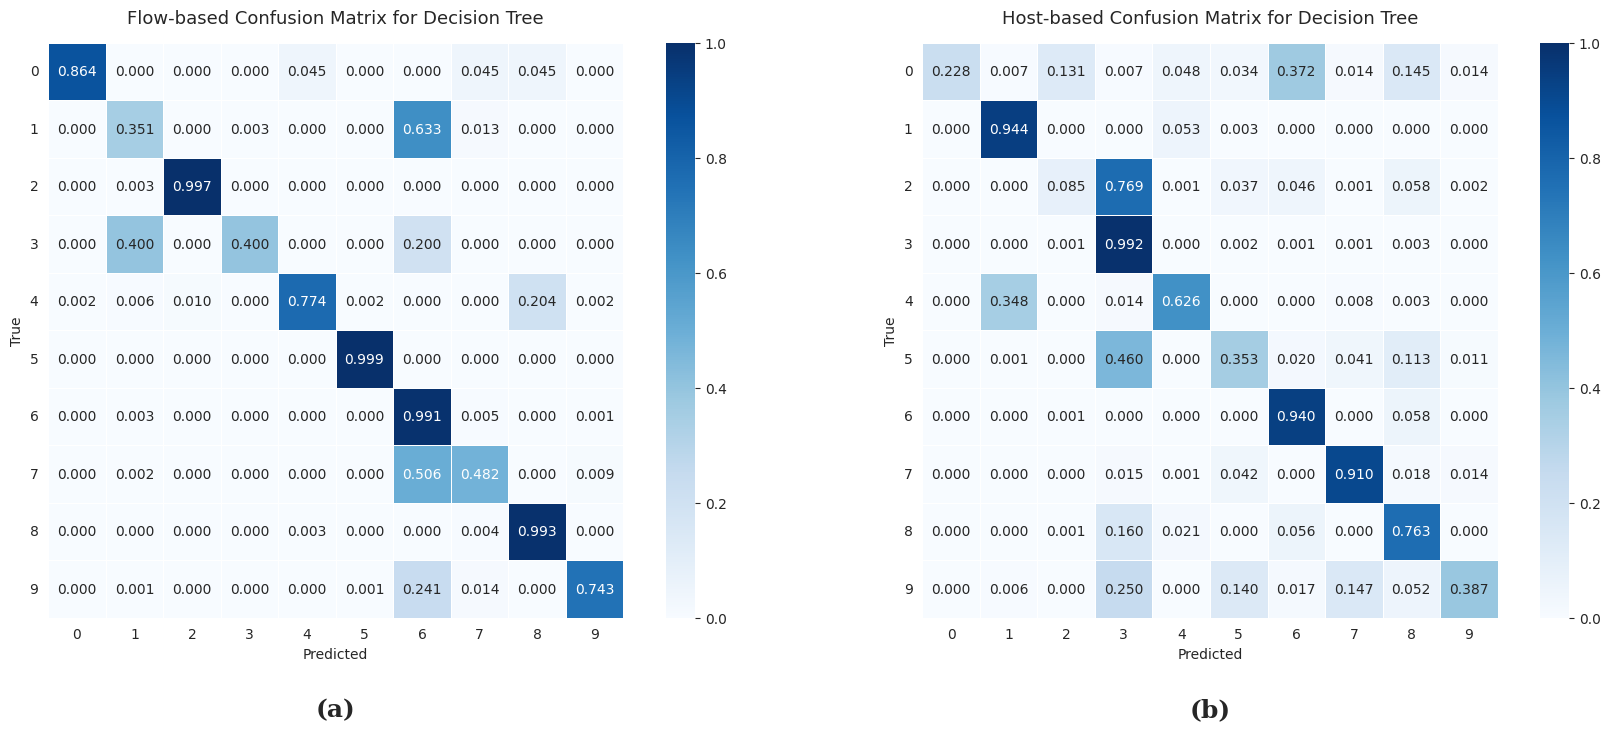

In [15]:
def normalized_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
    return np.nan_to_num(cm, nan=0.0)

def plot_reference_confusion_matrices():
    flow_cm = normalized_confusion_matrix(y_test_net, y_pred_net, net_labels)
    host_cm = normalized_confusion_matrix(y_test_sys, y_pred_sys, sys_labels)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(
        flow_cm,
        ax=axes[0],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=net_labels,
        yticklabels=net_labels,
        linewidths=0.5,
        linecolor="white",
    )
    axes[0].set_title("Flow-based Confusion Matrix for Decision Tree", fontsize=13, pad=14)
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    sns.heatmap(
        host_cm,
        ax=axes[1],
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        cbar=True,
        xticklabels=sys_labels,
        yticklabels=sys_labels,
        linewidths=0.5,
        linecolor="white",
    )
    axes[1].set_title("Host-based Confusion Matrix for Decision Tree", fontsize=13, pad=14)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)

    axes[0].text(
        0.5, -0.16, "(a)",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        family="serif",
    )
    axes[1].text(
        0.5, -0.16, "(b)",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        family="serif",
    )

    plt.tight_layout()
    plt.savefig("models/confusion_matrix_reference_style.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_reference_confusion_matrices()

## Network Flow Distribution


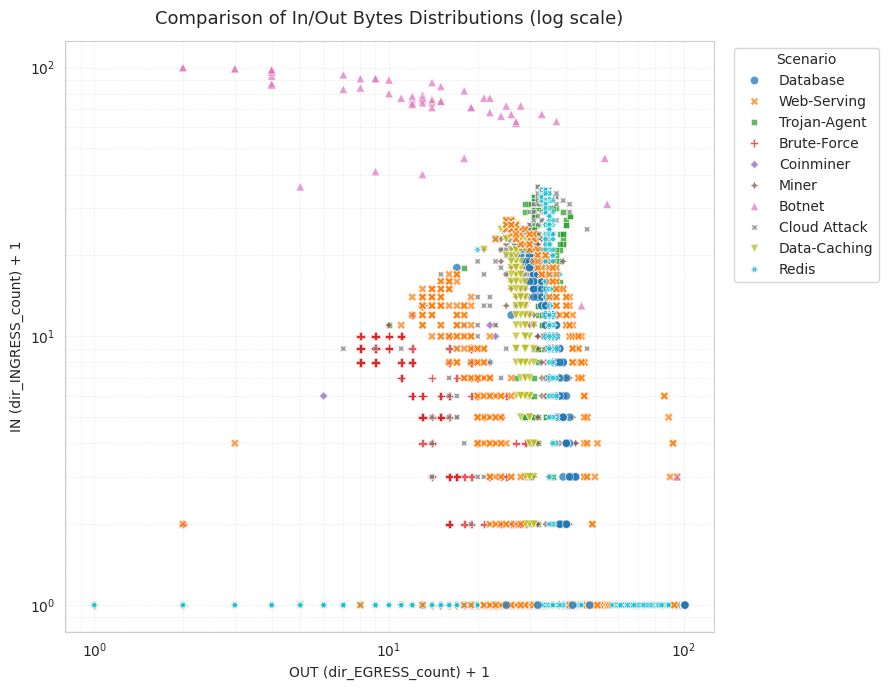

In [16]:
def first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def plot_figure7_style_flow_distribution(network_df):
    in_col = first_existing_column(
        network_df,
        [
            "IN_BYTES",
            "in_bytes",
            "input_bytes",
            "bytes_in",
            "dir_INGRESS_bytes",
            "dir_INGRESS_count",
        ],
    )
    out_col = first_existing_column(
        network_df,
        [
            "OUT_BYTES",
            "out_bytes",
            "output_bytes",
            "bytes_out",
            "dir_EGRESS_bytes",
            "dir_EGRESS_count",
        ],
    )

    if in_col is None or out_col is None:
        if {"dir_INGRESS_count", "dir_EGRESS_count"}.issubset(network_df.columns):
            in_col, out_col = "dir_INGRESS_count", "dir_EGRESS_count"
            title = "Comparison of In/Out Flow Count Distributions (log scale)"
        else:
            raise ValueError("No IN/OUT byte or ingress/egress count columns found.")
    else:
        title = "Comparison of In/Out Bytes Distributions (log scale)"

    plot_df = network_df.copy()
    scenario_col = "scenario_label" if "scenario_label" in plot_df.columns else "label"
    plot_df["class_name"] = plot_df[scenario_col].map(lambda label: SCENARIO_CLASS_NAMES[int(label)])
    plot_df["_in_value"] = plot_df[in_col].clip(lower=0) + 1
    plot_df["_out_value"] = plot_df[out_col].clip(lower=0) + 1

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.scatterplot(
        data=plot_df,
        x="_out_value",
        y="_in_value",
        hue="class_name",
        style="class_name",
        alpha=0.75,
        ax=ax,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel(f"OUT ({out_col}) + 1")
    ax.set_ylabel(f"IN ({in_col}) + 1")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.35)
    ax.legend(title="Scenario", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig("models/figure7_flow_distribution_style.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_figure7_style_flow_distribution(network_df)

## Dominant Syscall Sequences


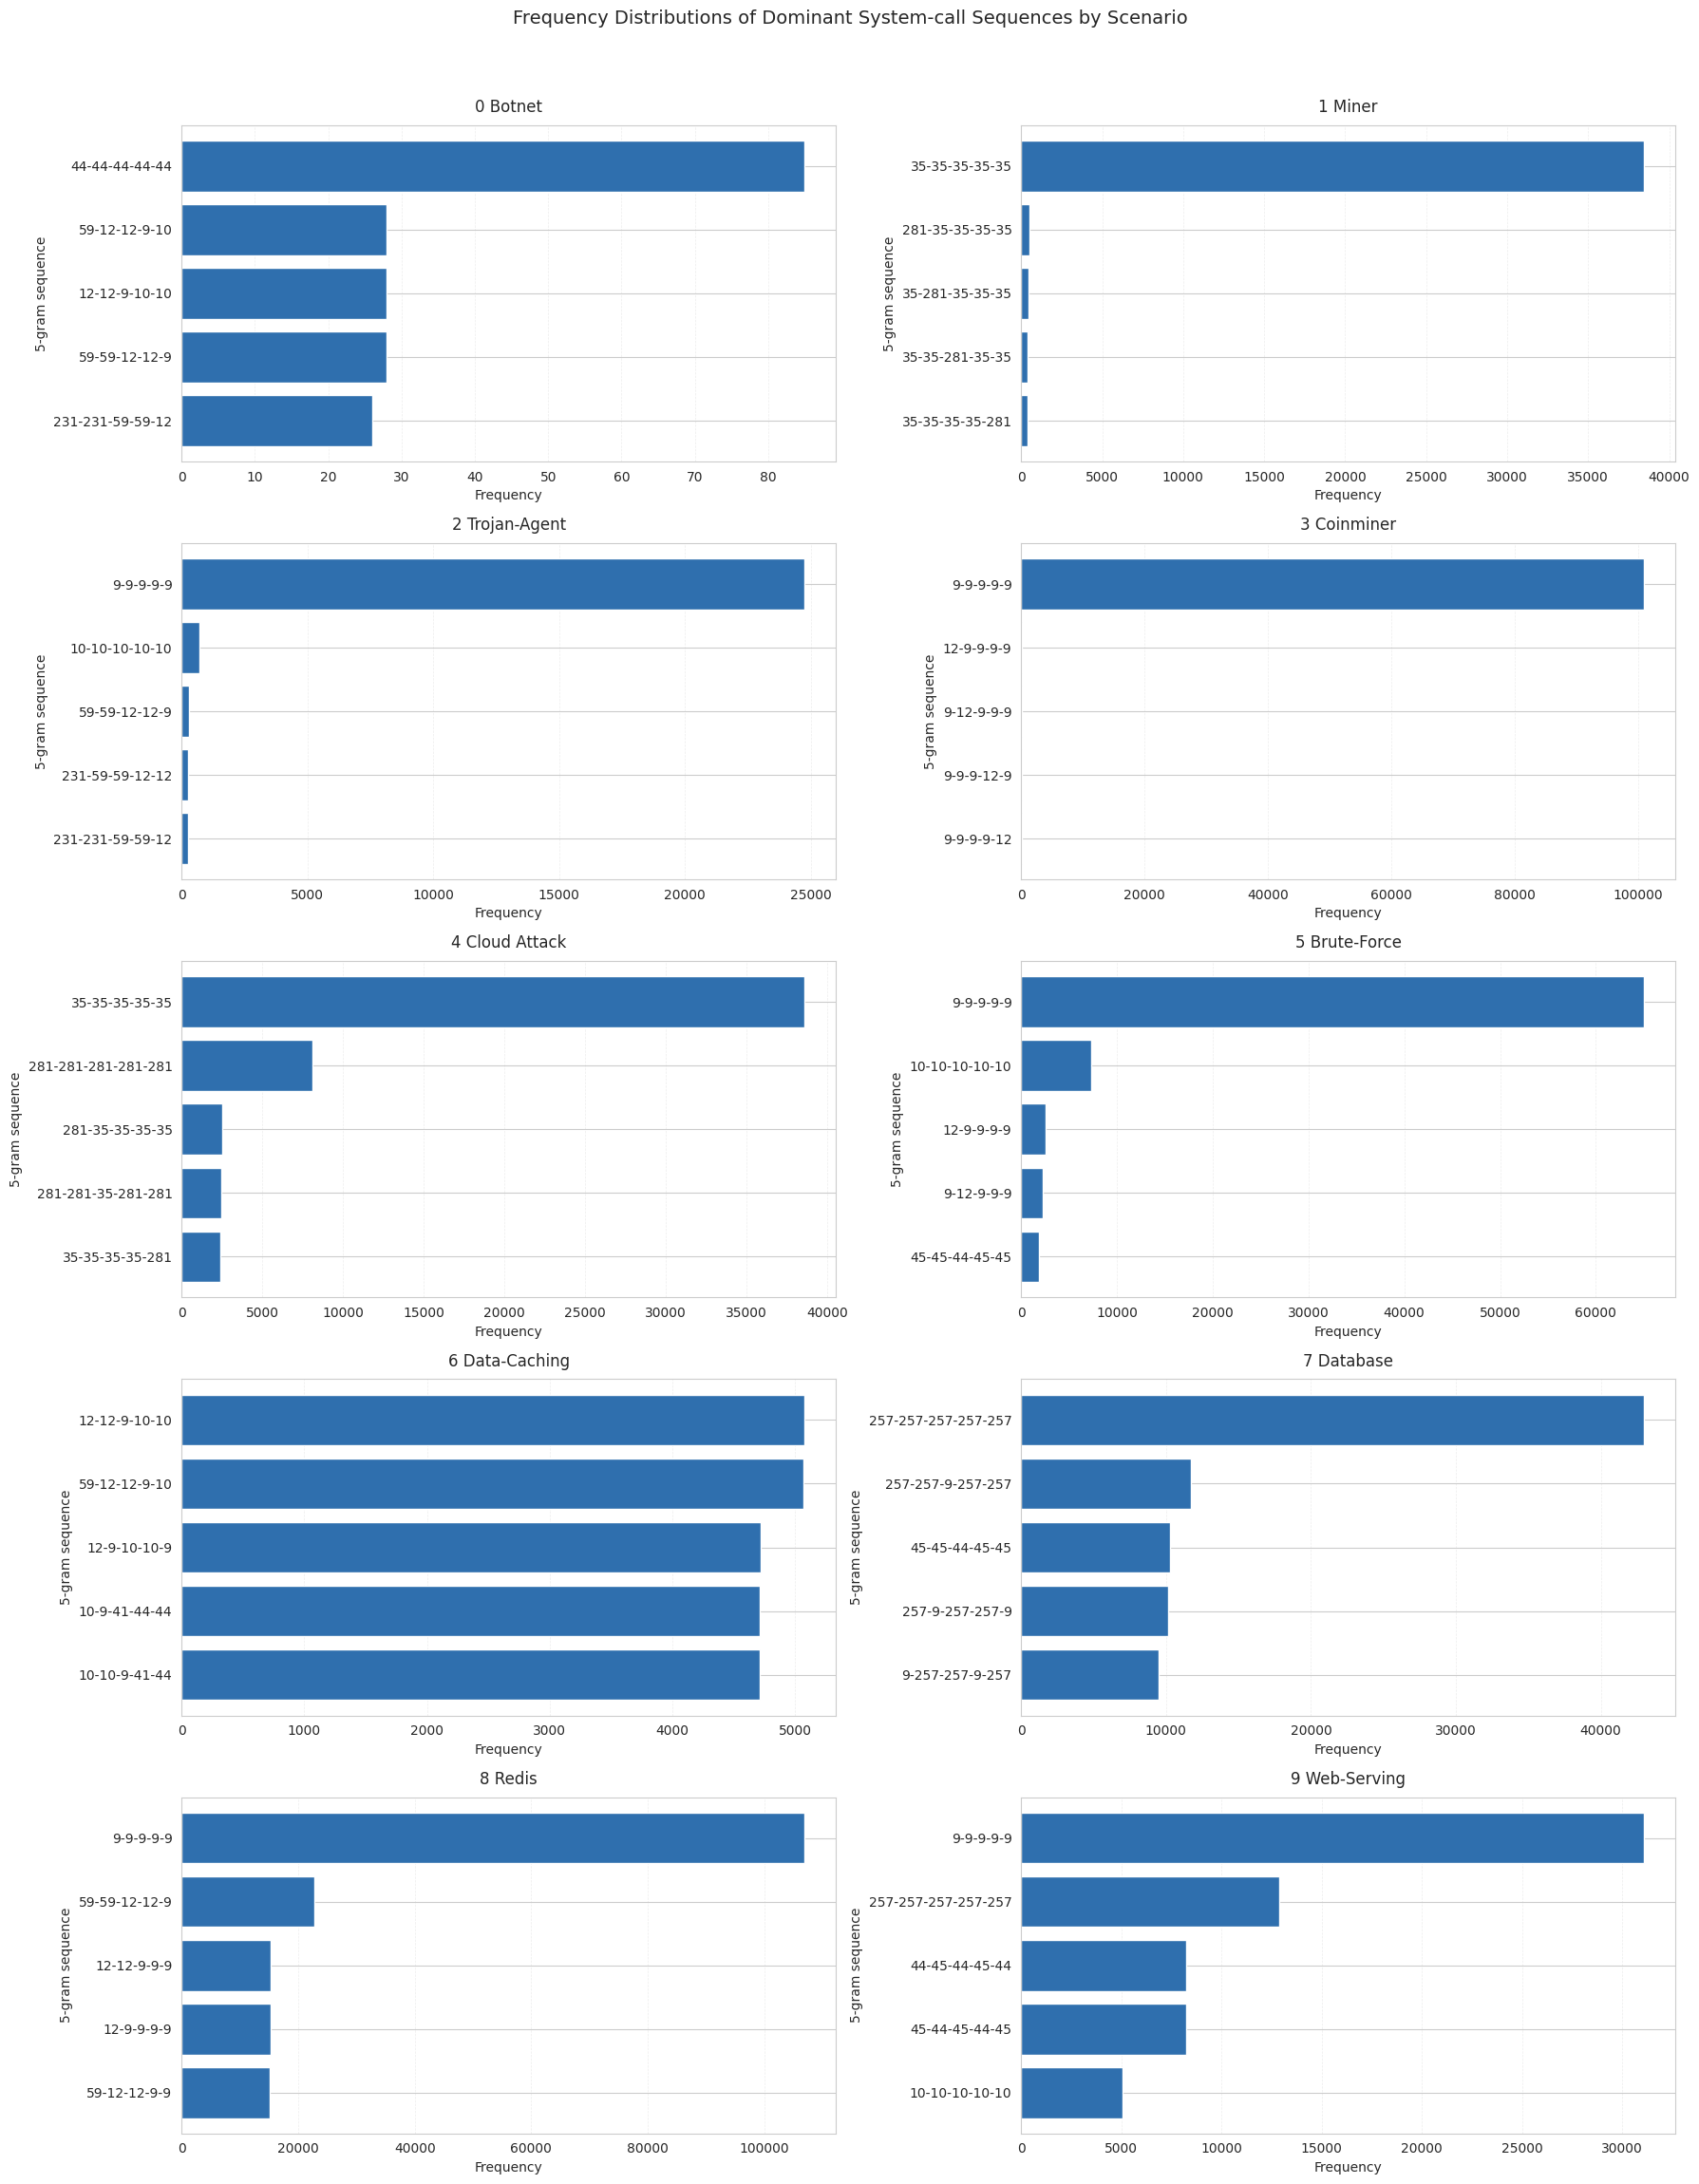

In [17]:
def format_ngram(row):
    return "-".join(str(int(row[col])) for col in ["n1", "n2", "n3", "n4", "n5"])

def plot_figure9_style_syscall_sequences(syscall_df, top_n=5):
    required = {"n1", "n2", "n3", "n4", "n5"}
    missing = required - set(syscall_df.columns)
    if missing:
        raise ValueError(f"Missing syscall n-gram columns: {sorted(missing)}")

    scenario_col = "scenario_label" if "scenario_label" in syscall_df.columns else "label"
    scenario_labels = sorted(syscall_df[scenario_col].unique())
    if not scenario_labels:
        raise ValueError("No scenario labels found in syscall dataset.")

    ncols = 2
    nrows = int(np.ceil(len(scenario_labels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, label in zip(axes, scenario_labels):
        subset = syscall_df[syscall_df[scenario_col] == label].copy()
        subset["sequence"] = subset.apply(format_ngram, axis=1)
        top = subset["sequence"].value_counts().head(top_n).sort_values()

        ax.barh(top.index, top.values, color="#2F6FAE")
        ax.set_title(f"{int(label)} {SCENARIO_CLASS_NAMES[int(label)]}", fontsize=12, pad=10)
        ax.set_xlabel("Frequency")
        ax.set_ylabel("5-gram sequence")
        ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.35)

    for ax in axes[len(scenario_labels):]:
        ax.axis("off")

    fig.suptitle(
        "Frequency Distributions of Dominant System-call Sequences by Scenario",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("models/figure9_syscall_sequences_style.png", dpi=200, bbox_inches="tight")
    plt.show()

plot_figure9_style_syscall_sequences(syscall_df)

## Feature Importance

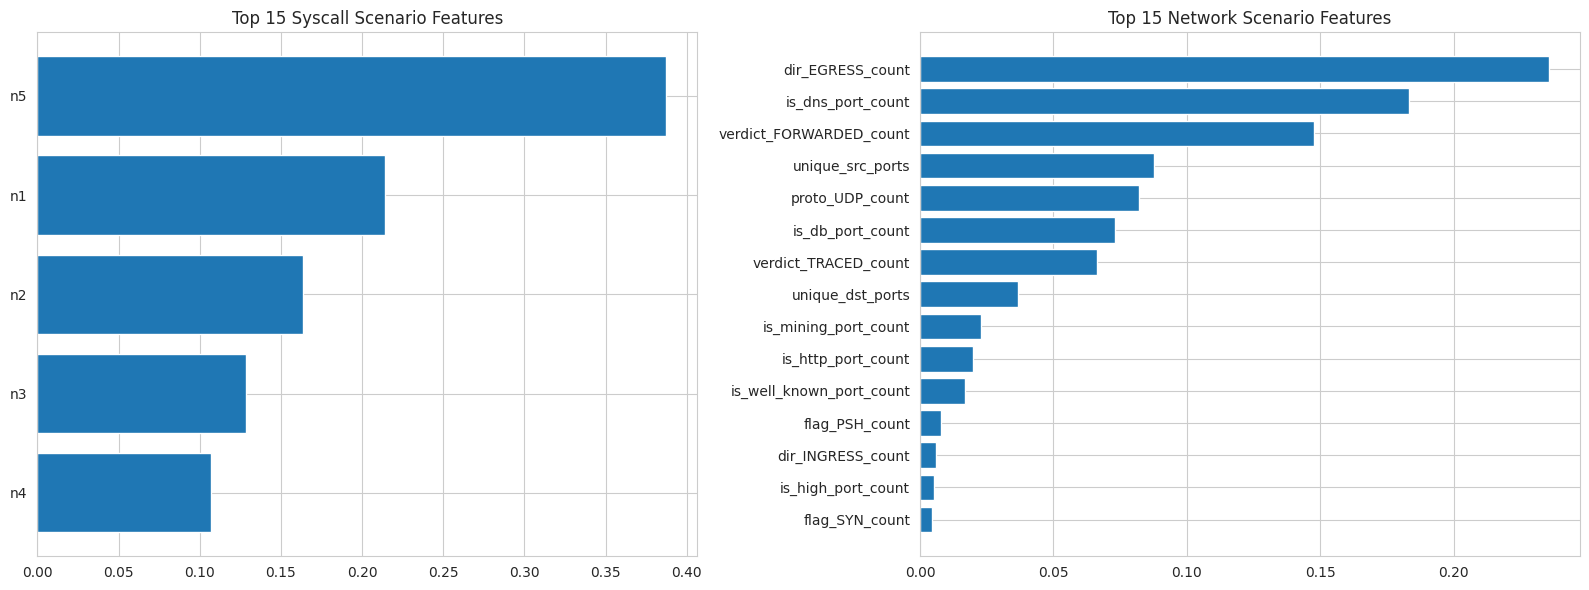

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_feature_importance(ax, model, columns, title):
    fi = (
        pd.DataFrame({"feature": columns, "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    ax.barh(range(len(fi)), fi["importance"])
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels(fi["feature"])
    ax.set_title(title)
    ax.invert_yaxis()

plot_feature_importance(axes[0], dt_syscall, X_syscall.columns, "Top 15 Syscall Scenario Features")
plot_feature_importance(axes[1], dt_network, X_network.columns, "Top 15 Network Scenario Features")

plt.tight_layout()
plt.show()


## Visualisasi Decision Tree

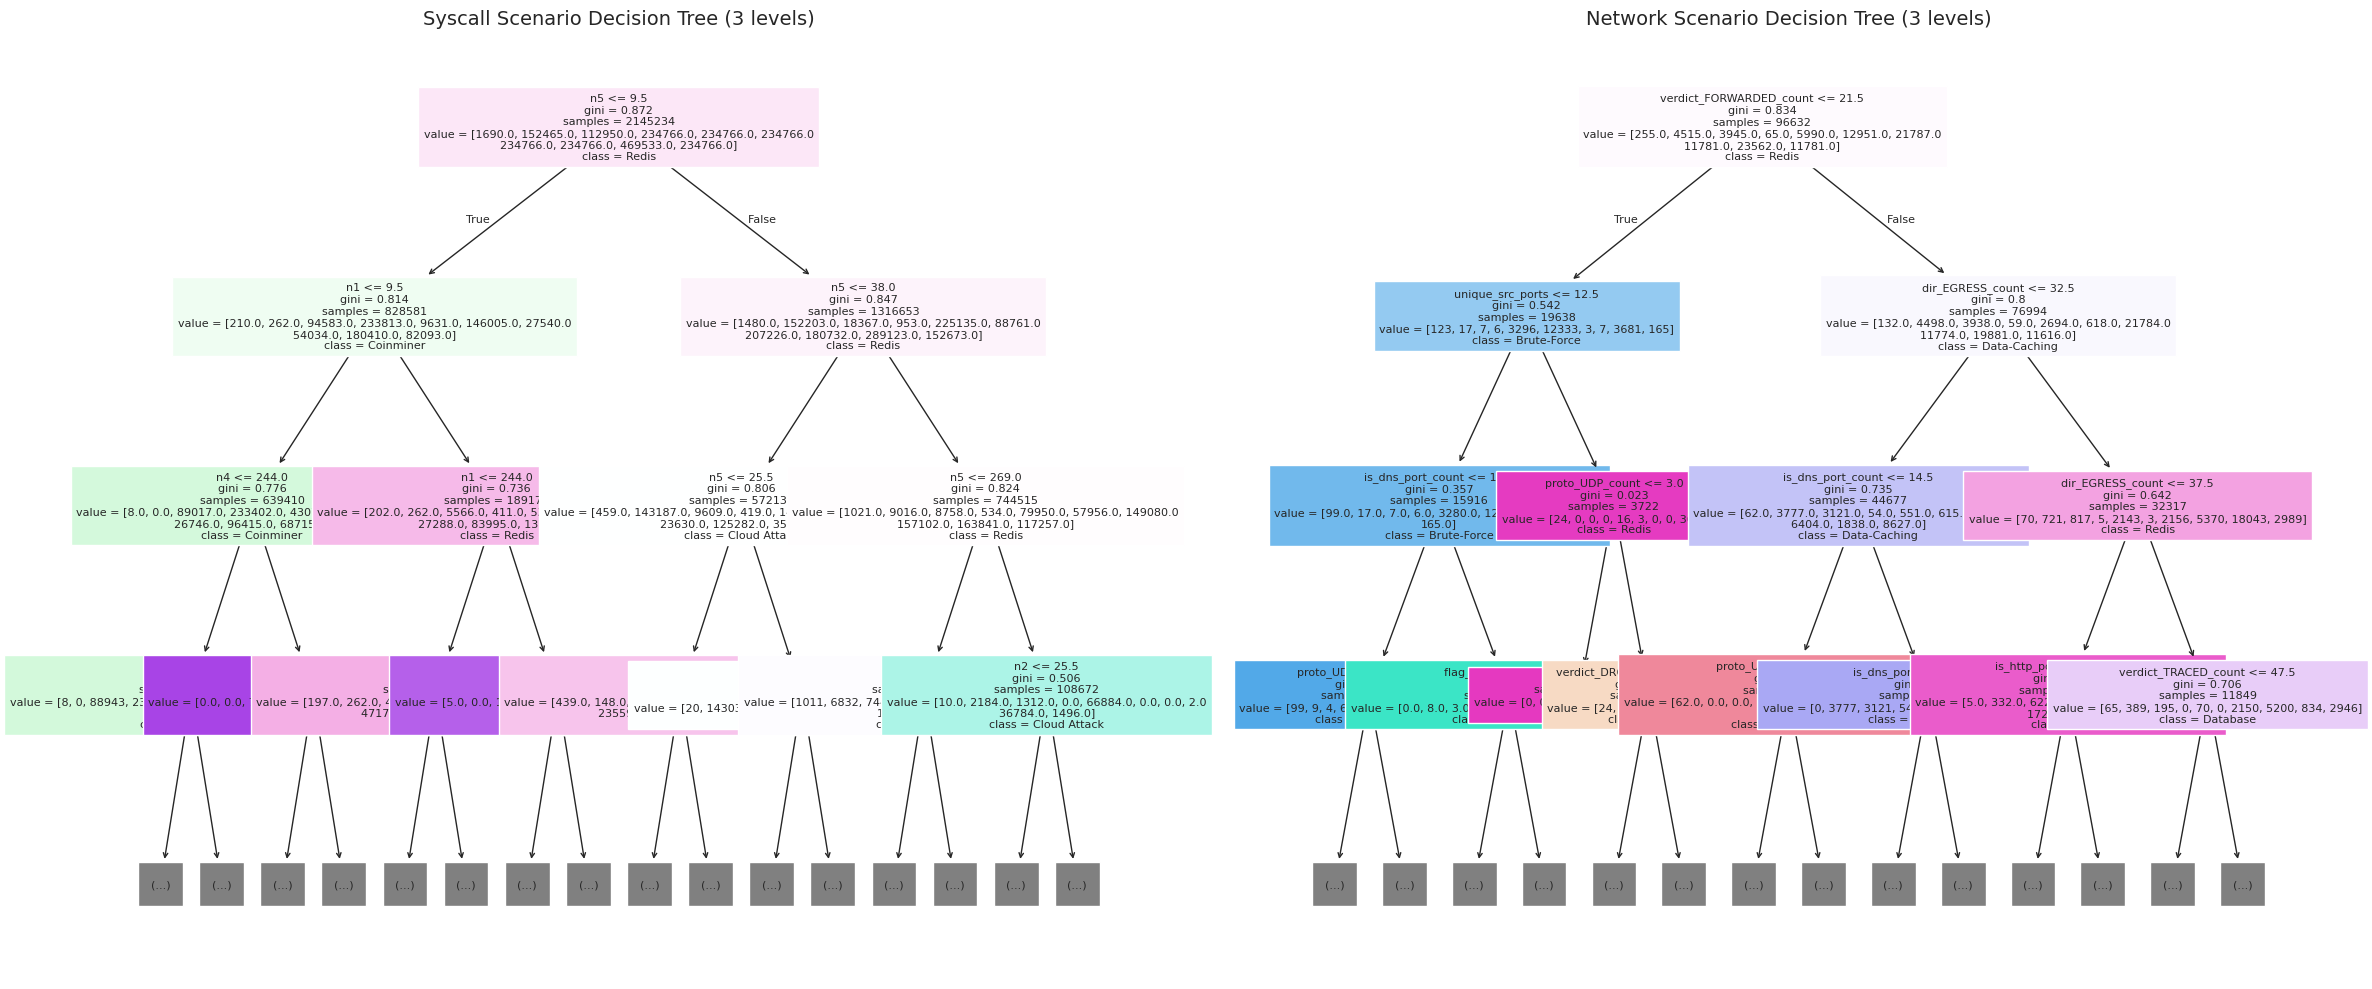

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

plot_tree(
    dt_syscall,
    max_depth=3,
    feature_names=X_syscall.columns,
    class_names=[SCENARIO_CLASS_NAMES[i] if 0 <= i < len(SCENARIO_CLASS_NAMES) else str(i) for i in sorted(dt_syscall.classes_)],
    filled=True,
    fontsize=8,
    ax=axes[0],
)
axes[0].set_title("Syscall Scenario Decision Tree (3 levels)", fontsize=14)

plot_tree(
    dt_network,
    max_depth=3,
    feature_names=X_network.columns,
    class_names=[SCENARIO_CLASS_NAMES[i] if 0 <= i < len(SCENARIO_CLASS_NAMES) else str(i) for i in sorted(dt_network.classes_)],
    filled=True,
    fontsize=8,
    ax=axes[1],
)
axes[1].set_title("Network Scenario Decision Tree (3 levels)", fontsize=14)

plt.tight_layout()
plt.show()

## Save Model

In [20]:
Path("models").mkdir(exist_ok=True)

# Save scenario models
joblib.dump(dt_syscall, "models/dt_syscall_scenario_model.pkl")
joblib.dump(dt_network, "models/dt_network_scenario_model.pkl")

# Save scaler fitted on syscall training data
from sklearn.preprocessing import StandardScaler
scaler_syscall = StandardScaler().fit(X_train_sys)
joblib.dump(scaler_syscall, "models/scaler_syscall.pkl")

# Backward-compatible aliases for existing loader code.
joblib.dump(dt_syscall, "models/dt_syscall_model.pkl")
joblib.dump(dt_network, "models/dt_network_model.pkl")

joblib.dump(X_syscall.columns.tolist(), "models/feature_names_syscall.pkl")
joblib.dump(X_network.columns.tolist(), "models/feature_names_network.pkl")
joblib.dump(SCENARIO_CLASS_NAMES, "models/scenario_class_names.pkl")

print("Scenario syscall model: models/dt_syscall_scenario_model.pkl")
print("Scenario network model: models/dt_network_scenario_model.pkl")
print("Scaler: models/scaler_syscall.pkl")
print("Feature names and scenario class names saved")


Scenario syscall model: models/dt_syscall_scenario_model.pkl
Scenario network model: models/dt_network_scenario_model.pkl
Scaler: models/scaler_syscall.pkl
Feature names and scenario class names saved
